In [1]:
!pip install -q git+https://github.com/RayenSansa03/aeroguard.git@main --force-reinstall --no-deps

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

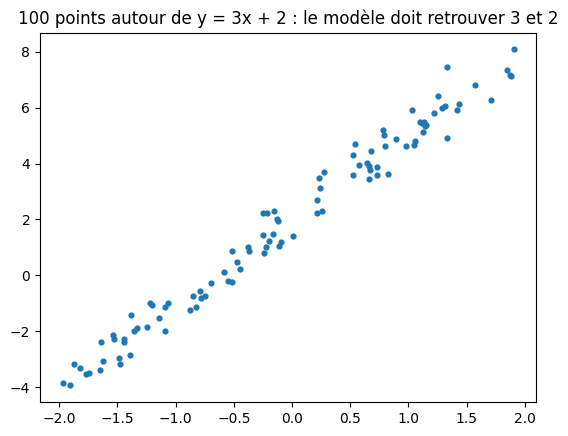

In [3]:
generateur = np.random.default_rng(42)
x_droite = generateur.uniform(-2, 2, size=100)
y_droite = 3.0 * x_droite + 2.0 + generateur.normal(0, 0.5, size=100)  # vraie droite : y = 3x + 2


def perte_mse(pente, ordonnee):
    """Altitude sur la colline : erreur quadratique moyenne."""
    return np.mean((pente * x_droite + ordonnee - y_droite) ** 2)


plt.scatter(x_droite, y_droite, s=12)
plt.title("100 points autour de y = 3x + 2 : le modèle doit retrouver 3 et 2")
plt.show()

In [4]:
pente, ordonnee = 0.0, 0.0      # départ : au sommet de la colline
taux_apprentissage = 0.1
historique_droite = []

for etape in range(30):
    erreur = pente * x_droite + ordonnee - y_droite        # 1. où est-ce qu'on se trompe ?
    gradient_pente = np.mean(2 * erreur * x_droite)         # 2. pente de la colline selon la pente
    gradient_ordonnee = np.mean(2 * erreur)                 #    et selon l'ordonnée
    pente -= taux_apprentissage * gradient_pente            # 3. un pas vers le bas
    ordonnee -= taux_apprentissage * gradient_ordonnee
    historique_droite.append({"etape": etape + 1, "pente": pente,
                              "ordonnee": ordonnee, "perte": perte_mse(pente, ordonnee)})

historique_droite = pd.DataFrame(historique_droite)
historique_droite.iloc[[0, 4, 9, 29]].round(3)

,etape,pente,ordonnee,perte
0,1,0.694,0.367,8.858
4,5,2.194,1.280,1.478
9,10,2.785,1.743,0.356
29,30,3.008,1.990,0.240


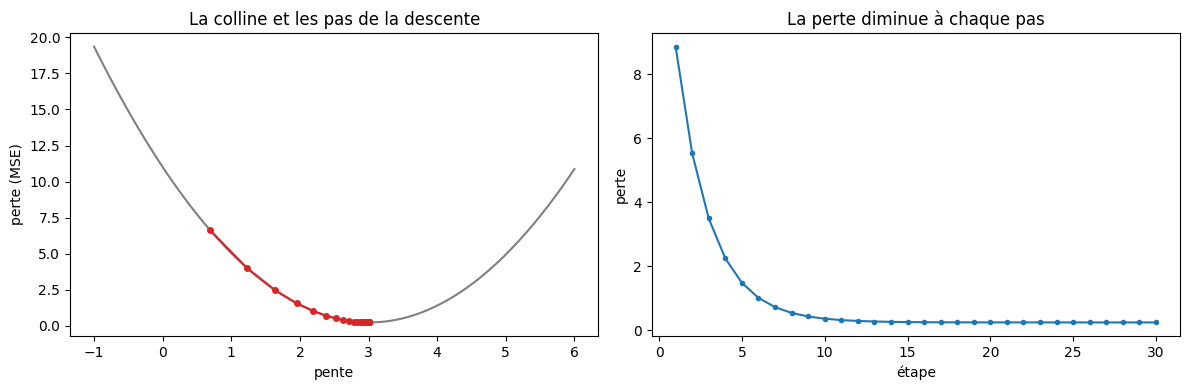

In [5]:
pentes_testees = np.linspace(-1, 6, 200)
altitudes = [perte_mse(p, 2.0) for p in pentes_testees]   # ordonnée fixée à 2 pour dessiner en 2D

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(pentes_testees, altitudes, color="gray")
axes[0].plot(historique_droite["pente"], [perte_mse(p, 2.0) for p in historique_droite["pente"]],
             "o-", color="tab:red", markersize=4)
axes[0].set_xlabel("pente")
axes[0].set_ylabel("perte (MSE)")
axes[0].set_title("La colline et les pas de la descente")

axes[1].plot(historique_droite["etape"], historique_droite["perte"], marker="o", markersize=3)
axes[1].set_xlabel("étape")
axes[1].set_ylabel("perte")
axes[1].set_title("La perte diminue à chaque pas")
plt.tight_layout()
plt.show()

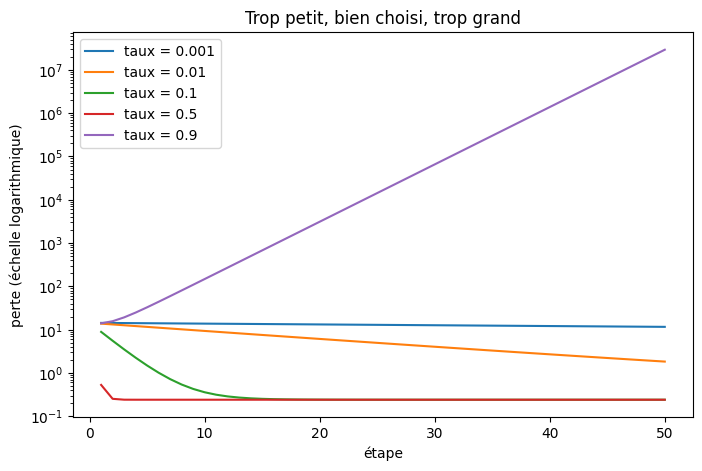

,taux,perte_finale,pente,ordonnee
0,0.001,1.157400e+01,0.328,0.176
1,0.010,1.824000e+00,2.069,1.212
2,0.100,2.400000e-01,3.010,1.993
3,0.500,2.400000e-01,3.010,1.994
4,0.900,2.930247e+07,-4771.723,1253.700


In [6]:
taux_a_tester = [0.001, 0.01, 0.1, 0.5, 0.9]
figure, axe = plt.subplots(figsize=(8, 5))
bilan_taux = []

for taux in taux_a_tester:
    pente, ordonnee = 0.0, 0.0
    pertes = []
    for etape in range(50):
        erreur = pente * x_droite + ordonnee - y_droite
        pente -= taux * np.mean(2 * erreur * x_droite)
        ordonnee -= taux * np.mean(2 * erreur)
        pertes.append(perte_mse(pente, ordonnee))
    axe.plot(range(1, 51), pertes, label=f"taux = {taux}")
    bilan_taux.append({"taux": taux, "perte_finale": pertes[-1],
                       "pente": pente, "ordonnee": ordonnee})

axe.set_yscale("log")
axe.set_xlabel("étape")
axe.set_ylabel("perte (échelle logarithmique)")
axe.set_title("Trop petit, bien choisi, trop grand")
axe.legend()
plt.show()

pd.DataFrame(bilan_taux).round(3)

In [7]:
from google.colab import drive
drive.mount("/content/drive")

from aeroguard.donnees_ml import preparer_xy
from aeroguard.evaluation import appliquer_seuil, metriques

DOSSIER = "/content/drive/MyDrive/aeroguard"
vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")

colonnes_neurone = ["T48_mean_montee", "Wf_mean_montee"]
moyennes = X_train[colonnes_neurone].mean()
ecarts_types = X_train[colonnes_neurone].std()


def normaliser(X):
    return ((X[colonnes_neurone] - moyennes) / ecarts_types).fillna(0).to_numpy()


Xn_train, Xn_val = normaliser(X_train), normaliser(X_val)
yv_train, yv_val = y_train.to_numpy(), y_val.to_numpy()
print("Train :", Xn_train.shape, "| Validation :", Xn_val.shape)

Mounted at /content/drive
Train : (3716, 2) | Validation : (819, 2)


In [8]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))


def perte_log(y_vrai, probas):
    """Log loss : punit fort les erreurs sûres d'elles."""
    probas = np.clip(probas, 1e-7, 1 - 1e-7)   # évite log(0)
    return -np.mean(y_vrai * np.log(probas) + (1 - y_vrai) * np.log(1 - probas))


def gradients(X, y_vrai, poids, biais):
    """Rétropropagation d'un neurone sigmoïde : erreur × entrée."""
    erreur = sigmoide(X @ poids + biais) - y_vrai
    return X.T @ erreur / len(y_vrai), erreur.mean()


# Exemple : la perte d'une prédiction sûre d'elle, juste ou fausse
print("Moteur usé, prédit à 99 % :", round(perte_log(np.array([1]), np.array([0.99])), 3))
print("Moteur usé, prédit à 50 % :", round(perte_log(np.array([1]), np.array([0.50])), 3))
print("Moteur usé, prédit à 1 %  :", round(perte_log(np.array([1]), np.array([0.01])), 3))

Moteur usé, prédit à 99 % : 0.01
Moteur usé, prédit à 50 % : 0.693
Moteur usé, prédit à 1 %  : 4.605


In [9]:
# On compare notre formule à une mesure directe de la pente : un tout petit pas de chaque côté
poids_test, biais_test, petit_pas = np.array([0.3, -0.2]), 0.1, 1e-5
gradient_formule, _ = gradients(Xn_train, yv_train, poids_test, biais_test)

gradient_mesure = []
for indice in range(2):
    decalage = np.zeros(2)
    decalage[indice] = petit_pas
    perte_plus = perte_log(yv_train, sigmoide(Xn_train @ (poids_test + decalage) + biais_test))
    perte_moins = perte_log(yv_train, sigmoide(Xn_train @ (poids_test - decalage) + biais_test))
    gradient_mesure.append((perte_plus - perte_moins) / (2 * petit_pas))

print("Gradient par la formule :", gradient_formule.round(6))
print("Gradient mesuré         :", np.round(gradient_mesure, 6))
assert np.allclose(gradient_formule, gradient_mesure, atol=1e-6)
print("✅ La rétropropagation est juste")

Gradient par la formule : [-0.140049 -0.075722]
Gradient mesuré         : [-0.140049 -0.075722]
✅ La rétropropagation est juste


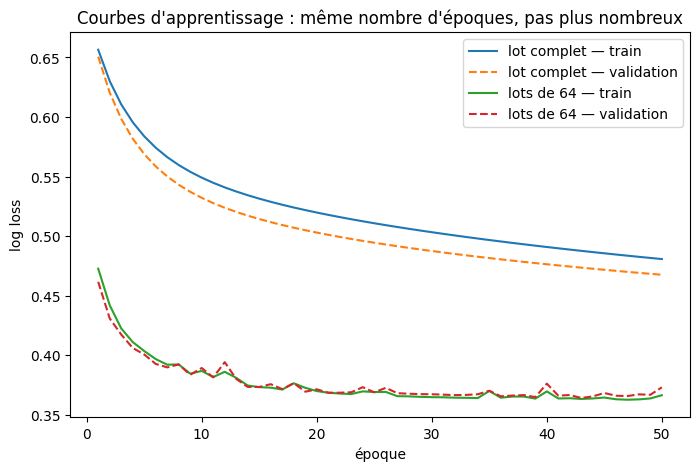

In [10]:
def entrainer_neurone(X, y, X_validation, y_validation, taux, epoques, taille_lot=None, graine=0):
    """Descente de gradient par lots. taille_lot=None : tous les vols à chaque pas."""
    generateur_lots = np.random.default_rng(graine)
    poids, biais = np.zeros(X.shape[1]), 0.0
    nombre_vols = len(y)
    taille = taille_lot or nombre_vols
    historique = []

    for epoque in range(epoques):
        ordre = generateur_lots.permutation(nombre_vols)       # mélanger les vols à chaque époque
        for debut in range(0, nombre_vols, taille):
            lot = ordre[debut:debut + taille]
            gradient_poids, gradient_biais = gradients(X[lot], y[lot], poids, biais)
            poids -= taux * gradient_poids
            biais -= taux * gradient_biais
        historique.append({
            "epoque": epoque + 1,
            "perte_train": perte_log(y, sigmoide(X @ poids + biais)),
            "perte_val": perte_log(y_validation, sigmoide(X_validation @ poids + biais)),
        })
    return poids, biais, pd.DataFrame(historique)


# 1) Lot complet : 1 pas par époque
poids_complet, biais_complet, historique_complet = entrainer_neurone(
    Xn_train, yv_train, Xn_val, yv_val, taux=0.5, epoques=50)

# 2) Mini-lots de 64 vols : beaucoup de pas par époque
poids_lots, biais_lots, historique_lots = entrainer_neurone(
    Xn_train, yv_train, Xn_val, yv_val, taux=0.5, epoques=50, taille_lot=64)

figure, axe = plt.subplots(figsize=(8, 5))
axe.plot(historique_complet["epoque"], historique_complet["perte_train"], label="lot complet — train")
axe.plot(historique_complet["epoque"], historique_complet["perte_val"], "--", label="lot complet — validation")
axe.plot(historique_lots["epoque"], historique_lots["perte_train"], label="lots de 64 — train")
axe.plot(historique_lots["epoque"], historique_lots["perte_val"], "--", label="lots de 64 — validation")
axe.set_xlabel("époque")
axe.set_ylabel("log loss")
axe.set_title("Courbes d'apprentissage : même nombre d'époques, pas plus nombreux")
axe.legend()
plt.savefig(f"{DOSSIER}/results/figures/42_courbes_apprentissage.png", dpi=150)
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression

regression = LogisticRegression().fit(Xn_train, yv_train)

comparaison = []
for nom, poids, biais in [
    ("Descente — lot complet (50 époques)", poids_complet, biais_complet),
    ("Descente — lots de 64 (50 époques)", poids_lots, biais_lots),
    ("sklearn (leçon 4.1)", regression.coef_[0], regression.intercept_[0]),
]:
    probas = sigmoide(Xn_val @ poids + biais)
    scores = metriques(yv_val, appliquer_seuil(probas, 0.5), probas)
    comparaison.append({"methode": nom, "poids_T48": poids[0], "poids_Wf": poids[1],
                        "biais": biais, "perte_val": perte_log(yv_val, probas),
                        "f1_macro": scores["f1_macro"]})

pd.DataFrame(comparaison).round(3)

,methode,poids_T48,poids_Wf,biais,perte_val,f1_macro
0,Descente — lot complet (50 époques),1.461,-0.295,1.107,0.468,0.430
1,Descente — lots de 64 (50 époques),9.117,-3.502,4.238,0.373,0.744
2,sklearn (leçon 4.1),8.556,-3.131,3.837,0.366,0.755
